In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import KNNModel

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

TEXTUAL_EMBEDDING_PATH = PROJECT_ROOT / 'data' / 'textual_features'
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'
text_emb_64 = TEXTUAL_EMBEDDING_PATH / 'textual_embeddings_64.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1

Using device: cuda
Project root: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1
Data: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\data\exploded_splits
Using device: cuda


# KNN based Model - on textual embeddings
By leveraging textual embeddings (128-dimensional vectors representing paper content), we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `KNNModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `StandardScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with embedding

In [2]:
df = pd.read_parquet(text_emb_64)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_054,ref_emb_055,ref_emb_056,ref_emb_057,ref_emb_058,ref_emb_059,ref_emb_060,ref_emb_061,ref_emb_062,ref_emb_063
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.256074,-0.008567,0.029544,0.027869,-0.039098,0.061620,...,0.076582,0.055348,-0.039177,0.056256,0.017018,0.043579,0.034777,0.014663,-0.034044,-0.054704
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.177240,0.009656,-0.006378,0.139191,0.036752,0.024424,...,-0.006508,0.031545,-0.055565,-0.011979,-0.008363,-0.009386,0.002395,-0.002766,0.006723,-0.022802
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.279532,-0.065988,0.089001,-0.124467,0.029971,-0.064336,...,0.038588,-0.011394,0.045359,0.087640,-0.039526,0.060604,-0.010542,-0.043045,-0.086090,-0.061507
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.279532,-0.065988,0.089001,-0.124467,0.029971,-0.064336,...,-0.075838,0.037070,-0.002920,-0.001729,0.016099,0.013601,0.073003,0.078989,-0.067062,-0.089302
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.279532,-0.065988,0.089001,-0.124467,0.029971,-0.064336,...,-0.031528,0.011389,-0.031854,-0.024054,0.068860,0.031421,-0.216782,0.017370,0.027655,-0.016881


(2950135, 132)


In [3]:
# splitting
split_series = df["split"].astype(str).str.lower()
df_train = df[split_series == "train"].copy()
df_val = df[split_series.isin(["validation", "val"])].copy()
df_test = df[split_series == "test"].copy()

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162513, 'test': 396380, 'val': 391242}


## 2. Baseline Model

[KNN_baseline] Preprocessing 2162513 rows...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN_baseline] Starting training...
Selected 2162/2162513
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       972
           1     1.0000    1.0000    1.0000      1190

    accuracy                         1.0000      2162
   macro avg     1.0000    1.0000    1.0000      2162
weighted avg     1.0000    1.0000    1.0000      2162



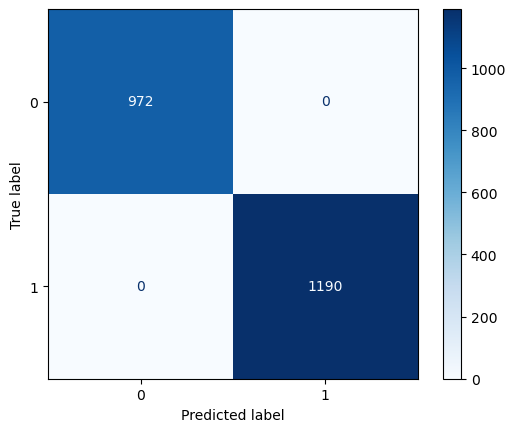

In [5]:
KNN_baseline = KNNModel('KNN_baseline', n_neighbors=5, weights='uniform', metric='minkowski', n_jobs=N_JOBS)
KNN_baseline.train_pipeline(df_train, frac=0.001, random_state=RANDOM_STATE)

[KNN_baseline] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
0    0.5023
1    0.4977
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.7852    0.6781    0.7277      5023
           1     0.7144    0.8127    0.7604      4977

    accuracy                         0.7451     10000
   macro avg     0.7498    0.7454    0.7441     10000
weighted avg     0.7499    0.7451    0.7440     10000



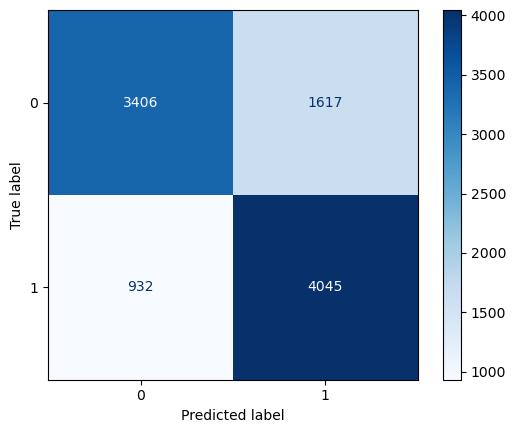

In [ ]:
KNN_baseline.test_pipeline(df_test.sample(10000))

## 3. Hypertuning
Given the high dimensionality of embeddings and the large number of records, KNN can be computationally expensive. To optimize performance, we perform `GridSearchCV` on a representative subset of the data.

We utilize a `PredefinedSplit` strategy. Instead of standard K-fold cross-validation, we manually specify which samples belong to the training fold and which belong to the validation fold. This ensures that the model is tuned on the exact data distribution intended for validation without leakage from the training set.

In [ ]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 10000
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

[KNN_textual_64] Grid Search...
[KNN_textual_64] Preprocessing 2162513 rows...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN_textual_64] Preprocessing 391242 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64

Starting tuning on 10000 samples...

Best parameters found:
{'metric': 'euclidean', 'n_neighbors': 12, 'weights': 'uniform'}

Optimal model ready: KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=12)
[KNN_textual_64] Train model with best params...
[KNN_textual_64] Preprocessing 2162513 rows...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[KNN_textual_64] Starting training...
Selected 21625/2162513
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      9833
           1     1.0000    1.0000    1.0000     11792

    accuracy                         1.0000     

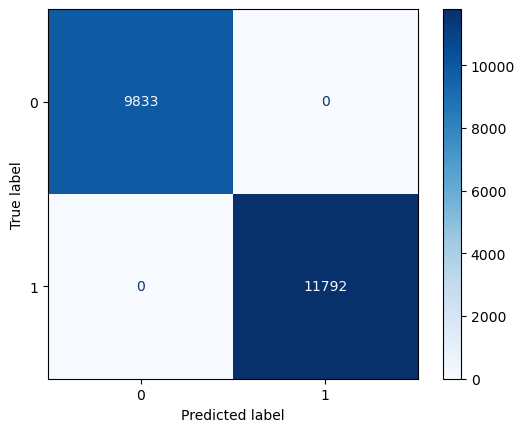

In [ ]:
# tuning
KNN_textual = KNNModel("KNN_textual_64")
KNN_textual.hypertune_pipeline(df_train, df_val, param_grid, 
                               max_tuning_samples=max_tuning_samples,
                               scoring='f1_weighted',
                               n_jobs=N_JOBS)

In [ ]:
text_emb_64 = TEXTUAL_EMBEDDING_PATH / 'textual_embeddings_128.parquet'
pd.read_parquet(text_emb_64)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.256074,-0.008567,0.029547,0.027875,-0.039097,0.061652,...,0.064212,0.001819,0.028266,0.074405,-0.012687,-0.012413,-0.018658,0.019843,-0.018603,-0.062412
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.177240,0.009653,-0.006376,0.139197,0.036759,0.024399,...,-0.002640,0.002758,-0.021711,0.000173,0.036031,0.010025,-0.032560,-0.004902,0.012356,-0.037394
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.025537,0.005557,0.027970,0.036103,0.017138,-0.040106,0.029802,-0.020301,-0.001983,-0.039484
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,0.022904,0.030194,0.019120,-0.022178,-0.037727,0.054251,-0.055143,0.056518,-0.040537,-0.131712
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.028705,-0.019178,-0.046387,-0.040602,0.018601,0.018564,0.042588,0.064933,0.001457,0.016216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2950130,test,5e56432693d709897cd2fbcd,5e4671853a55ac121dd335a5,0,0.329764,-0.023053,-0.005337,0.097310,0.021442,-0.002839,...,0.016288,-0.004156,-0.004709,0.007353,0.016632,-0.002789,0.007539,0.025798,0.026995,0.029713
2950131,test,6103d7c491e01159791b235f,65781f0d939a5f40824c131a,0,0.267742,-0.003383,-0.021759,0.006082,0.055654,-0.043690,...,0.024287,-0.030798,0.000678,0.036597,0.006076,-0.041304,-0.003875,0.005946,-0.005354,0.038623
2950132,test,66b4374a01d2a3fbfcc63b7b,5a73cb6a17c44a0b303590f3,0,0.366964,0.074186,-0.062492,0.041993,-0.055551,-0.064674,...,-0.056240,-0.019340,0.043722,0.016176,-0.005904,0.036845,-0.010512,-0.035559,-0.019805,-0.006738
2950133,test,5df0be543a55ac84bd7f488f,6389c6ee90e50fcafdc9c00d,0,0.315670,-0.083934,0.076030,-0.086718,0.163330,0.128246,...,0.017483,0.008490,-0.007176,0.041074,-0.093419,0.027127,0.075976,-0.018862,0.021063,0.018033


## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

[KNN_textual_64] Preprocessing 10000 rows...
Label distribution:
is_reference_valid
0    0.5029
1    0.4971
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.7887    0.7349    0.7609      5029
           1     0.7492    0.8008    0.7741      4971

    accuracy                         0.7677     10000
   macro avg     0.7689    0.7679    0.7675     10000
weighted avg     0.7691    0.7677    0.7675     10000



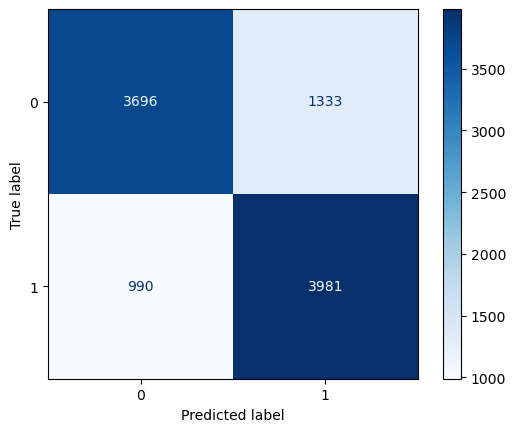

In [ ]:
KNN_textual.test_pipeline(df_test.sample(10000))

## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.

In [ ]:
from utils.model_saver import save_model_artifact

save_model_artifact(KNN_textual, df_name=text_emb_64.name, 
                    model_name="Best_KNN_textual_64", 
                    relative_model_dir=MODEL_SAVE_PATH)

Using device: cuda


NameError: name 'KNN_textual' is not defined